In [1]:
import os
from dotenv import load_dotenv
import mlflow
import spacy

load_dotenv()

nlp = spacy.load("pt_core_news_lg")

mlflow.set_tracking_uri("http://localhost:5001")
mlflow.set_experiment("ABC_Agent_Evaluation")
mlflow.langchain.autolog(log_traces=True)

c:\Users\Tales\Python\colectABA\ner-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import re
import ast
def parse_argilla_responses(response_str):
    if pd.isna(response_str): return []
    matches = re.findall(r"\{'end': \d+, 'label': '[^']+', 'start': \d+\}", response_str)
    parsed = []
    for m in matches:
        try: parsed.append(ast.literal_eval(m))
        except: pass
    return parsed

In [3]:
df_labeled = pd.read_csv('artefatos/ner_task/obs_diarias_ner_abc.csv')

df_labeled['entities'] = df_labeled['span_label.responses'].apply(parse_argilla_responses)
df_labeled = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(df_labeled) * 0.8)
df_test = df_labeled.iloc[split_idx:].copy()

In [4]:
import yaml
from langchain_openai import ChatOpenAI
with open('.config.yaml', 'r') as f:
    config = yaml.safe_load(f)

llm_provider = config['llm']['provider']
llm_config = config['llm']['models'][llm_provider]

llm = ChatOpenAI(
    model=llm_config['model_name'], 
    temperature=llm_config['temperature'],
    api_key=os.getenv("OPENAI_API_KEY")
)

In [5]:
from typing import List, Optional
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from classes import ABCEvaluationState

class Behavior(BaseModel):
    behavior: str = Field(
        description="O comportamento divergente exato extraído do texto. Copiado literalmente."
    )
    behavior_snippet: str = Field(
        description="A frase do texto original onde a ação ocorreu, envolvendo EXATAMENTE o comportamento com as tags <B> e </B>."
    )
class Behaviors(BaseModel):
    behaviors: Optional[List[Behavior]] = Field(
        default_factory=list,
        description="Lista de todos os comportamentos divergentes identificados. Retorne uma lista vazia se não houver nenhum."
    )

async def identify_behaviors_node(state: ABCEvaluationState) -> ABCEvaluationState:
    prompt = ChatPromptTemplate.from_template("""
        Você é um especialista em extração de dados clínicos em Análise do Comportamento Aplicada (ABA). 
        Sua tarefa é ler relatos de sessão e identificar APENAS as ações de comportamentos divergentes ou interferentes.
        DEFINIÇÃO:
        - Comportamento: A ação observável que é alvo de mudança. Pode ser uma ação ATIVA de alta intensidade (ex: se jogar no chão, gritar, bater, chorar, fuga) OU uma atitude PASSIVA/DE OPOSIÇÃO (ex: apresentar recusa, resistência, ignorar comandos, não engajar).
        
        DIRETRIZES CRÍTICAS:
        1. Extraia as substrings EXATAMENTE como aparecem no texto original.
        2. ANCORAGEM CONTEXTUAL: Para os campos 'snippet', retorne um trecho curto do texto original (5 a 10 palavras antes e depois) e envolva a extração exata com suas respectivas tags (<B></B> para comportamento).
        3. CORRESPONDÊNCIA EXATA DE TAGS: O texto que fica DENTRO da tag <B> DEVE ser rigorosamente idêntico ao que você colocou no campo 'behavior'. Exemplo: "o paciente <B>apresentou recusa</B> e depois fomos brincar."
        4. CUIDADO COM FALSOS NEGATIVOS: O fato de um relato terminar com frases como "sem intercorrências" ou "finalizou bem" NÃO anula os comportamentos divergentes (como recusas ou choros) que ocorreram no início ou meio da sessão. Extraia todos os eventos.
        5. ATENÇÃO: Atividades de rotina, comer, necessidades fisiológicas (fazer xixi/cocô no banheiro) e brincar adequadamente NÃO são comportamentos divergentes.
        
        Relato da sessão:
        {text}
    """
    )
    chain = prompt | llm.with_structured_output(Behaviors)
    response: Behaviors = await chain.ainvoke({"text": state["observation"]})
    if response.behaviors:
        behaviors_list = [
            item.behavior.strip() for item in response.behaviors if item.behavior.strip()
        ]
    else:
        behaviors_list = []
        
    return {"identified_behaviors": behaviors_list}

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from classes import ABCUnit, ABCEvaluationState

async def label_abc_context_node(state: ABCEvaluationState) -> ABCEvaluationState:
    episodes = []

    system_prompt = """Você é um especialista em Análise do Comportamento Aplicada (ABA). 
        Sua tarefa é analisar um relato clínico focando em um COMPORTAMENTO específico já identificado, e extrair o Antecedente e a Consequência exatos ligados a ele.

        DEFINIÇÕES:
        - Antecedente: Evento ou fator ambiental que ocorre imediatamente ANTES de um comportamento.
        - Comportamento: A ação observável em análise.
        - Consequência: O evento ou mudança ambiental que ocorre imediatamente APÓS o comportamento.

        DIRETRIZES CRÍTICAS:
        1. Extraia o Antecedente e a Consequência como CÓPIAS LITERAIS do texto. Não resuma.
        2. Se não houver descrição clara no texto para o antecedente ou consequência, retorne null no campo respectivo.
        3. O campo 'behavior' e 'behavior_snippet' fornecido deve ser retornado exatamente como enviado.
        4. ANCORAGEM CONTEXTUAL: Para os campos 'snippet', retorne um trecho curto do texto original (5 a 10 palavras antes e depois) e envolva a extração exata com suas respectivas tags (<A></A> para antecedente, <B></B> para comportamento, <C></C> para consequência).
        5. CORRESPONDÊNCIA EXATA DE TAGS: O texto que fica DENTRO da tag <A> DEVE ser rigorosamente idêntico ao que você colocou no campo 'antecedent'. O texto dentro de <C> deve ser idêntico ao campo 'consequence'. NUNCA envolva o comportamento com a tag <A> ou <C>.
        6. Forneça uma justificativa clínica clara e breve sobre a tríplice contingência identificada.

        ---
        EXEMPLO DE EXTRAÇÃO:

        **Exemplo 1**
        Relato: observation: 14:00 Ap: Panelas, itens de cozinha | Frutas | Animais Treinos: Jogo utilizando regras | Brincar Compartilhado | Troca de Turno | Frustração Laura chegou adequada e pediu para brincar com frutas, panelas e animais. Terapeuta permitiu desde que fosse combinado de realizar os treinos. Laura jogou o jogo da memória dos transportes com a terapeuta, chorou e cruzou os braços quando começou a contar o monte achado pela terapeuta e o dela, percebeu que estava perdendo, e apresentou esses comportamentos. Terapeuta ofertou papel e ela assoou o nariz, jogando o papel no lixo, continuou a brincar. Perdeu e chorou novamente, terapeuta fez o mesmo processo. Ela pediu para jogar novamente e a terapeuta aceitou, ela ganhou e comemorou. Terapeuta conversou com ela sobre ganhar e perder e se divertir. Como a sessão estava chegando ao final, terapeuta foi tirando o contato visual, pegou no celular enquanto ela chamava a atenção, jogando itens no chão quando terapeuta não respondia. Jogava e pedia "ajuda". Terapeuta puxou a cadeira para que ela pegasse, ainda sem contato visual. Terapeuta deixou apenas dois animais e duas frutas para que ela brincasse.Ela pegou do chão e voltou a brincar sozinha. Terapeuta colocou cronômetro e deu previsibilidade de ir embora, quando apitou, terapeuta já pegou na mão e foi levando até a recepção, imitando um dos animais que ela estava na mão, o leão e pedindo para ela imitar também. Finalizou bem e sem chorar.
        Comportamentos Foco: {{"behaviors": [{{"behavior": "chorou e cruzou os braços","behavior_snippet": "Laura jogou o jogo da memória dos transportes com a terapeuta, <B>chorou e cruzou os braços</B> quando começou a contar o monte achado pela terapeuta e o dela, percebeu que estava perdendo"}},{{"behavior": "chorou novamente","behavior_snippet": "jogando o papel no lixo, continuou a brincar. Perdeu e <B>chorou novamente</B>, terapeuta fez o mesmo processo."}},{{"behavior": "jogando itens no chão","behavior_snippet": "terapeuta foi tirando o contato visual, pegou no celular enquanto ela chamava a atenção, <B>jogando itens no chão</B> quando terapeuta não respondia."}}]}}
        Saída Esperada:
        ```json
        {{
            "antecedent": "percebeu que estava perdendo",
            "behavior": "chorou e cruzou os braços",
            "consequence": "Terapeuta ofertou papel",
            "antecedent_snippet": "contar o monte, <A>percebeu que estava perdendo</A>, e apresentou esses",
            "behavior_snippet": "terapeuta, <B>chorou e cruzou os braços</B> quando começou a contar",
            "consequence_snippet": "apresentou esses comportamentos. <C>Terapeuta ofertou papel</C> e ela assoou o nariz",
            "justification": "O primeiro episódio de choro ocorreu imediatamente após a frustração da perda no jogo. O manejo foi o acolhimento oferecendo papel."
        }},
        {{
            "antecedent": "Perdeu",
            "behavior": "chorou novamente",
            "consequence": "terapeuta fez o mesmo processo",
            "antecedent_snippet": "continuou a brincar. <A>Perdeu</A> e chorou novamente,",
            "behavior_snippet": "a brincar. Perdeu e <B>chorou novamente</B>, terapeuta fez o",
            "consequence_snippet": "Perdeu e chorou novamente, <C>terapeuta fez o mesmo processo</C>. Ela pediu para",
            "justification": "Novo episódio de choro gerado pela mesma contingência de perder o jogo. Manejo mantido."
        }},
        {{
            "antecedent": "terapeuta foi tirando o contato visual",
            "behavior": "jogando itens no chão",
            "consequence": "Terapeuta puxou a cadeira para que ela pegasse, ainda sem contato visual",
            "antecedent_snippet": "chegando ao final, <A>terapeuta foi tirando o contato visual</A>, pegou no celular enquanto ela chamava a atenção",
            "behavior_snippet": "ela chamava a atenção, <B>jogando itens no chão</B> quando terapeuta não",
            "consequence_snippet": "Jogava e pedia \"ajuda\". <C>Terapeuta puxou a cadeira para que ela pegasse, ainda sem contato visual</C>. Terapeuta deixou apenas",
            "justification": "O comportamento teve provável função de chamar atenção após a retirada de contato visual pela terapeuta. A consequência foi o auxílio físico sem reforço de atenção visual."
        }}
        ```

        **Exemplo 2**
        Relato: Daniel chegou tranquilo e animado, fomos para sala ele entrou e logo se sentou, aguardou o comando da professora, e enquanto ela organizava a sala e aguardava os colegas chegarem aproveitamos para realizar as demandas de hoje: • Pareamento de cor ( incentivo, ajuda física). • Pareamento de sombras (independente) • ⁠Pareamento de imagens não idênticas ( independente ) • ⁠Pareamento das vogais • ⁠Ouvinte (ajuda gestual). • ⁠Quebra cabeça (ajuda gestual) Daniel realizou as demandas com capricho atenção, ficou concentrado e realizou os comandos da AT como o esperado. Logo a professora de educação física chegou e entregou os blocos de montar e os brinquedos, com o intuito da socialização das crianças. Daniel permaneceu calmo durante as atividades e brincadeiras, não houve comportamento disruptivos, Daniel se socializou com os colegas e dividiu os brinquedos. A aula de educação física durou 45 minutos das 14h45 às 14h30 . Fomos ao banheiro para Daniel fazer xixi, e ao retornar para sala Daniel entrou sem chorar e continuou a brincadeira com os colegas, depois de alguns minutinhos a AT percebeu que ele queria ir ao banheiro, então fomos e ao chegar lá Daniel fez cocô, às 14h16. Então a AT aproveitou para dar um banho nele (não trocamos a roupa pois não houve necessidade). Ao retornar para a sala, Daniel teve resistência para entrar, se jogou no chão e ao ser fechada a porta o Daniel começou a chorar, mas logo se acalmou e ajudou a professora aguardar os brinquedos. Logo a professora começou a ler os cartazes. Daniel prestou atenção e permaneceu calmo. Às 15h00 fomos para o refeitório para lanchar, Daniel comeu o lanche que trouxe e ficou andando pelo pátio, esperando seus colegas terminar, após o lanche fomos ao banheiro para escovar os dentes, Daniel precisou de ajuda para escovar. Ao retornar para sala Daniel chorou ao entrar, porém não se jogou no chão. Sentou e em seguida a professora pediu para a AT realizar algumas atividades para ela avaliar o nível escolar do Daniel. Em seguida realizamos algumas atividades do livro junto com os colegas, com ajuda da At. Ao terminar Daniel ficou passeando pela sala enquanto esperava o horário de irmos embora. Faltando alguns minutos, pedimos permissão para a professora para irmos para o parquinho um pouco. Daniel brincou por alguns minutos, logo a AT percebeu que ele queria usar o banheiro então fomos, ao chegar Daniel fez cocô, depois de terminar foi para o chuveiro tomar banho, Daniel precisou de ajuda para passar o sabão no corpo. Ao sair fomos para as cadeira para esperar seus pais.
        Comportamento Foco: {{ "behaviors": [ {{ "behavior": "se jogou no chão", "behavior_snippet": "Ao retornar para a sala, Daniel teve resistência para entrar, <B>se jogou no chão</B> e ao ser fechada a porta o Daniel começou a chorar, mas logo se acalmou e ajudou a professora aguardar os brinquedos." }}, {{ "behavior": "começou a chorar", "behavior_snippet": "Ao retornar para a sala, Daniel teve resistência para entrar, se jogou no chão e ao ser fechada a porta o Daniel <B>começou a chorar</B>, mas logo se acalmou e ajudou a professora aguardar os brinquedos." }}, {{ "behavior": "chorou ao entrar", "behavior_snippet": "Ao retornar para sala Daniel <B>chorou ao entrar</B>, porém não se jogou no chão." }} ] }}
        Saída Esperada:
        ```json
        {{
            "antecedent": "Ao retornar para a sala",
            "behavior": "se jogou no chão",
            "consequence": null,
            "antecedent_snippet": "houve necessidade). <A>Ao retornar para a sala</A>, Daniel teve resistência  para",
            "behavior_snippet": "teve resistência  para entrar, <B>se jogou no chão</B> e ao ser fechada",
            "consequence_snippet": null,
            "justification": "O comportamento de se jogar no chão ocorreu na transição de volta para a sala. Não há descrição clínica de uma consequência ou manejo imediato para esta ação específica."
        }},
        {{
            "antecedent": "ao ser fechada a porta",
            "behavior": "começou a chorar",
            "consequence": null,
            "antecedent_snippet": "jogou no chão e <A>ao ser fechada a porta</A> o Daniel começou a",
            "behavior_snippet": "ao ser fechada a porta o Daniel <B>começou a chorar</B>, mas logo se acalmou",
            "consequence_snippet": null,
            "justification": "O choro foi engatilhado por uma nova mudança ambiental (fechar a porta). O relato indica que ele se acalmou sozinho, sem relatar uma consequência externa mediada."
        }},
        {{
            "antecedent": "Ao retornar para sala",
            "behavior": "chorou ao entrar",
            "consequence": null,
            "antecedent_snippet": "ajuda  para escovar. <A>Ao retornar para sala</A> Daniel chorou ao entrar,",
            "behavior_snippet": "Ao retornar para sala Daniel <B>chorou ao entrar</B>, porém não se jogou",
            "consequence_snippet": null,
            "justification": "O choro ocorreu novamente devido à demanda de transição (retornar para a sala). Nenhuma consequência ou manejo imediato foi relatado."
        }}
        ```
        """
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "Relato: '{text}'\nComportamento Foco: '{behavior}'")
    ])
    chain = prompt |  llm.with_structured_output(ABCUnit)

    for behavior in state["identified_behaviors"]:
        try:
            result = await chain.ainvoke({
                "text": state["observation"], 
                "behavior": behavior
            })
            episodes.append(result)
        except Exception as e:
            print(f"Erro ao extrair ABC para '{behavior}': {e}")
            pass
            
    return {"final_episodes": episodes}

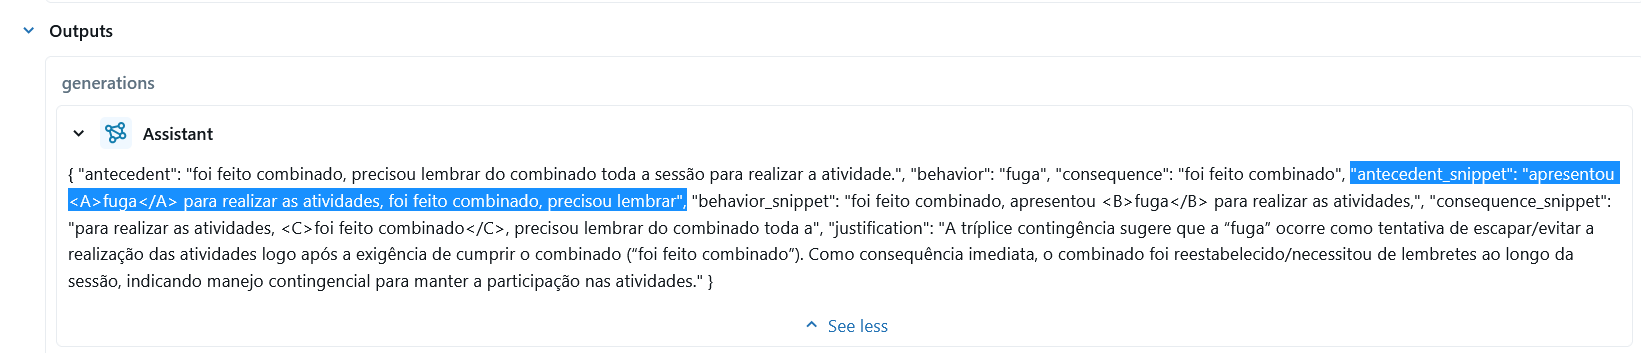

In [7]:
from langgraph.graph import END
def router_logic(state: ABCEvaluationState):
    if not state.get("identified_behaviors"):
        return END
    return "label_abc_context"

In [8]:
from langgraph.graph import START, END, StateGraph

builder = StateGraph(ABCEvaluationState)
builder.add_node("identify_behaviors", identify_behaviors_node)
builder.add_node("label_abc_context", label_abc_context_node)

builder.set_entry_point("identify_behaviors")
builder.add_edge(START, "identify_behaviors")
builder.add_conditional_edges("identify_behaviors", router_logic, {
    "label_abc_context": "label_abc_context",
    END: END
})
builder.add_edge("label_abc_context", END)
agent_labeler = builder.compile()

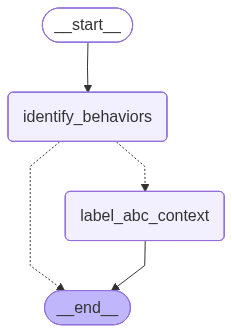

In [9]:
from IPython.display import Image, display

imagem_grafo = agent_labeler.get_graph().draw_mermaid_png()
display(Image(imagem_grafo))

## Classificação utilizando o agente

In [10]:
# def extrair_spans_do_agente(text, final_episodes):
#     res = []
#     if not final_episodes:
#         return res
        
#     for episodio in final_episodes:
#         ## Antecedente
#         if episodio.antecedent:
#             for match in re.finditer(re.escape(episodio.antecedent), text, re.IGNORECASE):
#                 res.append({"start": match.start(), "end": match.end(), "text": match.group(), "label": "ANTECEDENTE"})
        
#         ## Comportamento
#         if hasattr(episodio, 'behavior') and episodio.behavior:
#             for match in re.finditer(re.escape(episodio.behavior), text, re.IGNORECASE):
#                 res.append({"start": match.start(), "end": match.end(), "text": match.group(), "label": "COMPORTAMENTO"})
                
#         ## Consequência
#         if episodio.consequence:
#             for match in re.finditer(re.escape(episodio.consequence), text, re.IGNORECASE):
#                 res.append({"start": match.start(), "end": match.end(), "text": match.group(), "label": "CONSEQUENCIA"})
                
#     res.sort(key=lambda x: x["start"])
#     return res

In [11]:
def localizar_span_ancorado(texto_completo, snippet_tagueado, tag):
    if not snippet_tagueado or not texto_completo:
        return None
        
    ## Regex para capturar os grupos (prefixo, a entidade e o sufixo)
    pattern = rf"(.*?)<{tag}>(.*?)</{tag}>(.*)"
    match = re.search(pattern, snippet_tagueado, re.DOTALL | re.IGNORECASE)
    
    if not match:
        return None
        
    prefixo, entidade, sufixo = match.groups()
    snippet_limpo = prefixo + entidade + sufixo ## Limpo a tag para fazer o match direto no texto
    
    ## Localizar onde o snippet limpo começa
    inicio_snippet = texto_completo.find(snippet_limpo)
    
    if inicio_snippet != -1:
        start_idx = inicio_snippet + len(prefixo)
        end_idx = start_idx + len(entidade)
        return {"start": start_idx, "end": end_idx, "text": entidade}
    # fallback_match = re.search(re.escape(entidade), texto_completo, re.IGNORECASE)
    # if fallback_match:
    #     return {"start": fallback_match.start(), "end": fallback_match.end(), "text": entidade}     
    return None

In [12]:
def extrair_spans_do_agente(text, final_episodes):
    res = []
    if not final_episodes:
        return res
    for episodio in final_episodes:
        ant_snip = getattr(episodio, 'antecedent_snippet', None) or (episodio.get('antecedent_snippet') if isinstance(episodio, dict) else None)
        beh_snip = getattr(episodio, 'behavior_snippet', None) or (episodio.get('behavior_snippet') if isinstance(episodio, dict) else None)
        con_snip = getattr(episodio, 'consequence_snippet', None) or (episodio.get('consequence_snippet') if isinstance(episodio, dict) else None)
        
        ## Antecedente/Tag A
        span_a = localizar_span_ancorado(text, ant_snip, 'A')
        if span_a:
            span_a["label"] = "ANTECEDENTE"
            res.append(span_a)
            
        ## Comportamento/Tag B
        span_b = localizar_span_ancorado(text, beh_snip, 'B')
        if span_b:
            span_b["label"] = "COMPORTAMENTO"
            res.append(span_b)
            
        ## Consequência/Tag C
        span_c = localizar_span_ancorado(text, con_snip, 'C')
        if span_c:
            span_c["label"] = "CONSEQUENCIA"
            res.append(span_c)
            
    res_unicos = []
    vistos = set()
    for r in res:
        tupla_id = (r["start"], r["end"], r["label"])
        if tupla_id not in vistos:
            vistos.add(tupla_id)
            res_unicos.append(r)
            
    res_unicos.sort(key=lambda x: x["start"])
    return res_unicos

In [13]:
# df_test = df_test[:5]

In [14]:
import logging
import warnings

logging.getLogger("mlflow.utils.autologging_utils").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [15]:
import json
import pandas as pd
from tqdm import tqdm

async def generate_and_save_predictions(df, agent, output_path="agent_predictions.csv"):
    results = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extraindo com Agente"):
        text = str(row["text"])
        true_entities = row.get("entities", [])
        
        try:
            output = await agent.ainvoke({"observation": text})
            episodes_pred = output.get("final_episodes", [])
        except Exception as e:
            print(f"Erro na extração do texto índice {idx}: {e}")
            episodes_pred = []
            
        pred_dicts = extrair_spans_do_agente(text, episodes_pred)
        
        results.append({
            "text": text,
            "true_entities": json.dumps(true_entities, ensure_ascii=False),
            "pred_entities": json.dumps(pred_dicts, ensure_ascii=False),
            "raw_episodes": json.dumps([ep if isinstance(ep, dict) else ep.model_dump() for ep in episodes_pred], ensure_ascii=False)
        })
        
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_path, index=False, encoding='utf-8')
    return df_results

df_preds_salvo = await generate_and_save_predictions(df_test, agent_labeler, "artefatos/agent_predictions.csv")

Extraindo com Agente: 100%|██████████| 100/100 [08:31<00:00,  5.12s/it]


[Trace(trace_id=tr-a1d30dcec236c96edc71d83b98977e93), Trace(trace_id=tr-1be86f6ac59aa2f49f7c5a5f60c15756), Trace(trace_id=tr-4e3b0457de8b817186c9743d09097a05), Trace(trace_id=tr-d9e2ee73ff03862e82e7ab9354a4522f), Trace(trace_id=tr-520b7661b4fcf4c2082216ab42273c68), Trace(trace_id=tr-d6e0221a11269ab293c61a0707e13dfa), Trace(trace_id=tr-57c865a0b82f58be499bbad6ecbd2927), Trace(trace_id=tr-c0f5ba579b9c1ec0c1b6764549168614), Trace(trace_id=tr-c3edca92019f5089cca21b4f73f8e5e0), Trace(trace_id=tr-9aa491167f407465ceda8bbd1bb9d342)]

In [16]:
from spacy import displacy

def visualize_agent_predictions(text, predictions, colors=None):
    """
    Renderiza o texto com as marcações de A, B e C.
    Adaptado para ler a chave 'label' gerada pelo extrair_spans_do_agente.
    """
    default_colors = {
        "ANTECEDENTE": "#ADD8E6",   
        "COMPORTAMENTO": "#FFB6C1", 
        "CONSEQUENCIA": "#98FB98",  
    }
    colors = colors or default_colors
    text = str(text)
    doc = nlp(text)
    ents = []
    ent_start = -1
    
    for ent in predictions:
        span = doc.char_span(
            ent["start"],
            ent["end"],
            label=ent["label"],
            alignment_mode="expand"
        )
        if span is not None:
            if len(ents) > 0 and span.start_char == ent_start:
                ents.pop()
            ent_start = span.start_char
            ents.append({
                "start": ent_start,
                "end": span.end_char,
                "label": ent["label"]
            })
            
    displacy_data = {
        "text": text,
        "ents": ents,
        "title": "Extração ABC - Agente LangGraph"
    }
    
    displacy.render(
        [displacy_data],
        style="ent",
        manual=True,
        jupyter=True,
        options={"colors": colors}
    )

In [17]:
df_preds_salvo

,text,true_entities,pred_entities,raw_episodes
0,"Daniel chegou tranquilo e animado, fomos para...","[{""end"": 1343, ""label"": ""COMPORTAMENTO"", ""star...","[{""start"": 1320, ""end"": 1356, ""text"": ""Daniel ...","[{""antecedent"": ""Ao retornar para a sala"", ""be..."
1,lanche oferecido mas criança não consumiu \nne...,[],[],"[{""antecedent"": null, ""behavior"": ""criança não..."
2,O atendimento clínico foi realizado das 9h às ...,[],[],[]
3,"18:00\nAv: sapo, aramado, robô\nTreinos: mando...","[{""end"": 146, ""label"": ""COMPORTAMENTO"", ""start...","[{""start"": 131, ""end"": 146, ""text"": ""apresento...","[{""antecedent"": ""Leônidas chegou adequado e ap..."
4,REMANEJAMENTO \nEm atendimento o paciente apre...,"[{""end"": 58, ""label"": ""COMPORTAMENTO"", ""start""...","[{""start"": 41, ""end"": 76, ""text"": ""apresentou ...","[{""antecedent"": ""Em atendimento o paciente apr..."
...,...,...,...,...
95,Laura foi pra sessão com brinquedos de montar!...,[],[],[]
96,Atendimento desmarcado pela terapeita por ques...,[],[],[]
97,"Atendimento em clínica, realizado de 08:12 às ...",[],[],[]
98,Data: 28/08/2025\nHorário: 13h00 às 14h00\nPac...,"[{""end"": 695, ""label"": ""ANTECEDENTE"", ""start"":...","[{""start"": 808, ""end"": 917, ""text"": ""foi utili...","[{""antecedent"": ""logo no início foi perceptíve..."


In [18]:
from IPython.display import display, HTML

def visualizar_amostra_do_csv(df_amostra):
    for idx, row in df_amostra.iterrows():
        texto = row["text"]
        if isinstance(row["pred_entities"], str):
            spans_pred = json.loads(row["pred_entities"])
        else:
            spans_pred = row["pred_entities"]
        
        print(f"--- Documento ID: {idx} ---")
        
        visualize_agent_predictions(texto, spans_pred)
        
        if "raw_episodes" in row and pd.notna(row["raw_episodes"]):
            episodes_pred = json.loads(row["raw_episodes"]) if isinstance(row["raw_episodes"], str) else row["raw_episodes"]
            if episodes_pred:
                display(HTML("<b>Detalhes Extraídos:</b>"))
                for i, ep in enumerate(episodes_pred):
                    justificativa = ep.get("justification", "Sem justificativa")
                    print(f"  [{i+1}] Justificativa Clínica: {justificativa}")
            else:
                print("  Nenhum comportamento divergente identificado.")
        else:
            print("  (Justificativas não disponíveis. Adicione 'raw_episodes' ao CSV para visualizá-las.)")
            
        print('-'*100, '\n')

In [19]:

df_salvo = pd.read_csv("artefatos/agent_predictions.csv")
visualizar_amostra_do_csv(df_salvo[:5])

--- Documento ID: 0 ---


  [1] Justificativa Clínica: O relato indica que o comportamento de se jogar no chão ocorreu imediatamente após a transição de volta para a sala (antecedente: retorno para a sala). Não há menção explícita de uma consequência imediata específica para esse ato (ex.: manejo, retirada de acesso ou reforço direto), apenas que depois da porta fechada o Daniel começou a chorar e, em seguida, se acalmou.
  [2] Justificativa Clínica: O choro ocorreu imediatamente após a mudança ambiental especificada (“ao ser fechada a porta”), indicando um provável comportamento de resposta à aversividade/recusa na transição. O relato não descreve uma consequência ambiental imediata contingente ao choro (ex.: fuga/atenção/ajuda específica), apenas que ele “logo se acalmou”, então a consequência não pôde ser extraída literalmente.
  [3] Justificativa Clínica: O relato indica que a resistência para entrar ocorreu imediatamente na transição de retorno para a sala. Não há descrição explícita de uma consequência im

  [1] Justificativa Clínica: O relato descreve apenas que o lanche foi oferecido e que a criança não consumiu. Não há informação suficiente para identificar o evento imediatamente anterior (antecedente) nem o que ocorreu imediatamente após (consequência) especificamente para esse comportamento.
---------------------------------------------------------------------------------------------------- 

--- Documento ID: 2 ---


  Nenhum comportamento divergente identificado.
---------------------------------------------------------------------------------------------------- 

--- Documento ID: 3 ---


  [1] Justificativa Clínica: O relato descreve que a fuga aparece imediatamente quando o aluno chega e tenta iniciar as atividades; em seguida, a terapeuta estabelece/retoma o combinado e ele precisa lembrar do combinado durante toda a sessão para conseguir realizar a tarefa (consequência de manejo/estruturação do ambiente para manter acesso às atividades).
---------------------------------------------------------------------------------------------------- 

--- Documento ID: 4 ---


  [1] Justificativa Clínica: A recusa ocorreu imediatamente no contexto do início do atendimento (antecedente: em atendimento o paciente apresentou). Como consequência imediata, o terapeuta alterou o estímulo/manejo direcionando e ofertando a bola, e em seguida houve engajamento (bola) com provável reforço funcional por acesso a item.
---------------------------------------------------------------------------------------------------- 



## Avaliação

In [23]:
import evaluate
from transformers import AutoTokenizer
from helpers.ner import convert_to_IOB
def evaluate_strict_from_csv(df, tokenizer_name="neuralmind/bert-base-portuguese-cased"):
    df["true_entities"] = df["true_entities"].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df["pred_entities"] = df["pred_entities"].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    metric = evaluate.load("seqeval")
    
    all_true_labels = []
    all_pred_labels = []
    
    for idx, row in df.iterrows():
        text = str(row["text"])
        
        ## Ground Truth Spans -> IOB
        true_spans = [(ent["start"], ent["end"], text[ent["start"]:ent["end"]], ent["label"].upper()) for ent in row["true_entities"]]
        true_iob = convert_to_IOB(true_spans, text, tokenizer)
        all_true_labels.append([tag for _, tag in true_iob])
        
        ## Prediction Spans -> IOB
        pred_spans = [(ent["start"], ent["end"], ent["text"], ent["label"].upper()) for ent in row["pred_entities"]]
        pred_iob = convert_to_IOB(pred_spans, text, tokenizer)
        all_pred_labels.append([tag for _, tag in pred_iob])

    results = metric.compute(predictions=all_pred_labels, references=all_true_labels)
    
    print(f"Precisão : {results['overall_precision']:.4f}")
    print(f"Recall   : {results['overall_recall']:.4f}")
    print(f"F1       : {results['overall_f1']:.4f}")
    print(f"Acurácia : {results['overall_accuracy']:.4f}")
    print("Por classe:")
    print('-'*75)
    for label, metrics in {k: v for k, v in results.items() if isinstance(v, dict)}.items():
        print(f"{label} -> Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f}")

# Executar
evaluate_strict_from_csv(df_preds_salvo)

Precisão : 0.1240
Recall   : 0.1159
F1       : 0.1199
Acurácia : 0.9135
Por classe:
---------------------------------------------------------------------------
ANTECEDENTE -> Precision: 0.0233 | Recall: 0.0345 | F1: 0.0278
COMPORTAMENTO -> Precision: 0.2239 | Recall: 0.1667 | F1: 0.1911
CONSEQUENCIA -> Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


In [21]:
## Intersection over Union
def calcular_iou(span_true, span_pred):
    start_max = max(span_true['start'], span_pred['start'])
    end_min = min(span_true['end'], span_pred['end'])
    intersecao = max(0, end_min - start_max)
    
    uniao = max(span_true['end'], span_pred['end']) - min(span_true['start'], span_pred['start'])
    return intersecao / uniao if uniao > 0 else 0

In [22]:
def evaluate_relaxed_from_dataframe(df_preds, iou_threshold=0.3):
    print(f"Avaliação | IoU >= {iou_threshold}")
    
    labels = ["ANTECEDENTE", "COMPORTAMENTO", "CONSEQUENCIA"]
    metrics = {label: {"TP": 0, "FP": 0, "FN": 0} for label in labels}
    
    for _, row in df_preds.iterrows():
        true_ents = json.loads(row["true_entities"]) if isinstance(row["true_entities"], str) else row["true_entities"]
        pred_ents = json.loads(row["pred_entities"]) if isinstance(row["pred_entities"], str) else row["pred_entities"]
        true_spans = [{"start": t["start"], "end": t["end"], "label": t["label"].upper()} for t in true_ents]
        pred_spans = [{"start": p["start"], "end": p["end"], "label": p["label"].upper()} for p in pred_ents]
        
        ## Para cada Label calular o TP, FP, FN
        for label in labels:
            trues_label = [t for t in true_spans if t["label"] == label]
            preds_label = [p for p in pred_spans if p["label"] == label]
            
            matched_trues = set()
            matched_preds = set()
            
            ## Parear a melhor predição com o Ground Truth
            for i, p_span in enumerate(preds_label):
                melhor_iou = 0
                melhor_true_idx = -1
                
                for j, t_span in enumerate(trues_label):
                    # if j in matched_trues:
                    #     continue ## Pula se o gabarito já foi pareado com outra predição
                    
                    iou = calcular_iou(t_span, p_span)
                    if iou > melhor_iou:
                        melhor_iou = iou
                        melhor_true_idx = j
                
                ## Se o IOU for >= ao limite, é um Acerto (TP)
                if melhor_iou >= iou_threshold:
                    metrics[label]["TP"] += 1
                    matched_trues.add(melhor_true_idx)
                    matched_preds.add(i)
                else:
                    ## Não houve uma sobreposição >= que o limiar (FP)
                    metrics[label]["FP"] += 1
                    
            ## Gabaritos sem match, omissões (FN)
            metrics[label]["FN"] += len(trues_label) - len(matched_trues)

    print("Por Classe:")
    total_tp, total_fp, total_fn = 0, 0, 0
    
    for label, counts in metrics.items():
        tp, fp, fn = counts["TP"], counts["FP"], counts["FN"]
        total_tp += tp
        total_fp += fp
        total_fn += fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"{label} -> Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

    ## Média Global
    micro_p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    micro_r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    micro_f1 = 2 * (micro_p * micro_r) / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0
    
    print(f"\nMÉDIA GLOBAL -> Precision: {micro_p:.4f} | Recall: {micro_r:.4f} | F1: {micro_f1:.4f}")

df_predicoes_salvas = pd.read_csv("artefatos/agent_predictions.csv")

evaluate_relaxed_from_dataframe(df_predicoes_salvas, iou_threshold=0.3)

Avaliação | IoU >= 0.3
Por Classe:
ANTECEDENTE -> Precision: 0.0862 | Recall: 0.1724 | F1: 0.1149
COMPORTAMENTO -> Precision: 0.4493 | Recall: 0.3444 | F1: 0.3899
CONSEQUENCIA -> Precision: 0.3158 | Recall: 0.3158 | F1: 0.3158

MÉDIA GLOBAL -> Precision: 0.2877 | Recall: 0.3043 | F1: 0.2958


## Mudança sugerida

um certo dia `<B>` fulano chorou debaixo da mesa`</B>` e depois...

Para o objeto ABCUnit 
Retornar toda a frase com as tags de classificação

Mais a frente usar ids
um certo dia `<id=1 comportamento>` fulano chorou debaixo da mesa`</comportamento>` e depois...

## LLM-As-a-Judge
Quantidade de acertos (A,B,C)
Relação de causa e consequencia (Posterior)

## Serviço para API
Devemos implementar na api, mesmo como uma POC.

Observações diárias:
2025-10-28 => 3021 X
2025-10-27 => 6087
2025-10-26 => 239
2025-10-25 => 294
2025-10-24 => 4928
2025-10-23 => 5573
2025-10-22 => 6045
2025-10-21 => 6192

In [28]:
## Análise de custos
x = 4*(6192+6045+5573+4928+294+239+6087)
print(x/463*0.301) ## Reais/Mês

76.34348164146868
